In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

In [95]:
available_games = {
    'Ch': chicken_2player, 
    'PD': prisoners_dilemma_2player, 
    'SH': stag_hunt_2player, 
    'Ha': harmony_2player
}

def get_game_name(this_game, available_games):
    for key, game in available_games.items():
        if torch.equal(this_game, game):
            return key
    return None

Simulation: n=20 agents playing 41 games
(0, 6) -- SH
(0, 7) -- Ha
(0, 13) -- Ha
(0, 14) -- Ch
(0, 16) -- Ch
(1, 2) -- Ha
(1, 5) -- SH
(1, 10) -- PD
(1, 12) -- Ha
(1, 16) -- Ch
(2, 4) -- SH
(2, 8) -- Ha
(2, 11) -- Ha
(2, 19) -- SH
(3, 4) -- Ha
(3, 7) -- SH
(3, 8) -- PD
(3, 14) -- SH
(5, 10) -- SH
(5, 12) -- SH
(5, 15) -- Ha
(5, 17) -- Ha
(5, 19) -- SH
(6, 7) -- Ha
(6, 10) -- Ch
(6, 15) -- Ch
(7, 17) -- Ha
(8, 10) -- Ha
(8, 11) -- SH
(8, 13) -- PD
(8, 15) -- Ha
(9, 11) -- Ch
(9, 12) -- SH
(10, 17) -- Ha
(11, 19) -- Ch
(12, 17) -- Ch
(13, 14) -- PD
(15, 17) -- SH
(16, 19) -- SH
(17, 18) -- PD
(18, 19) -- PD


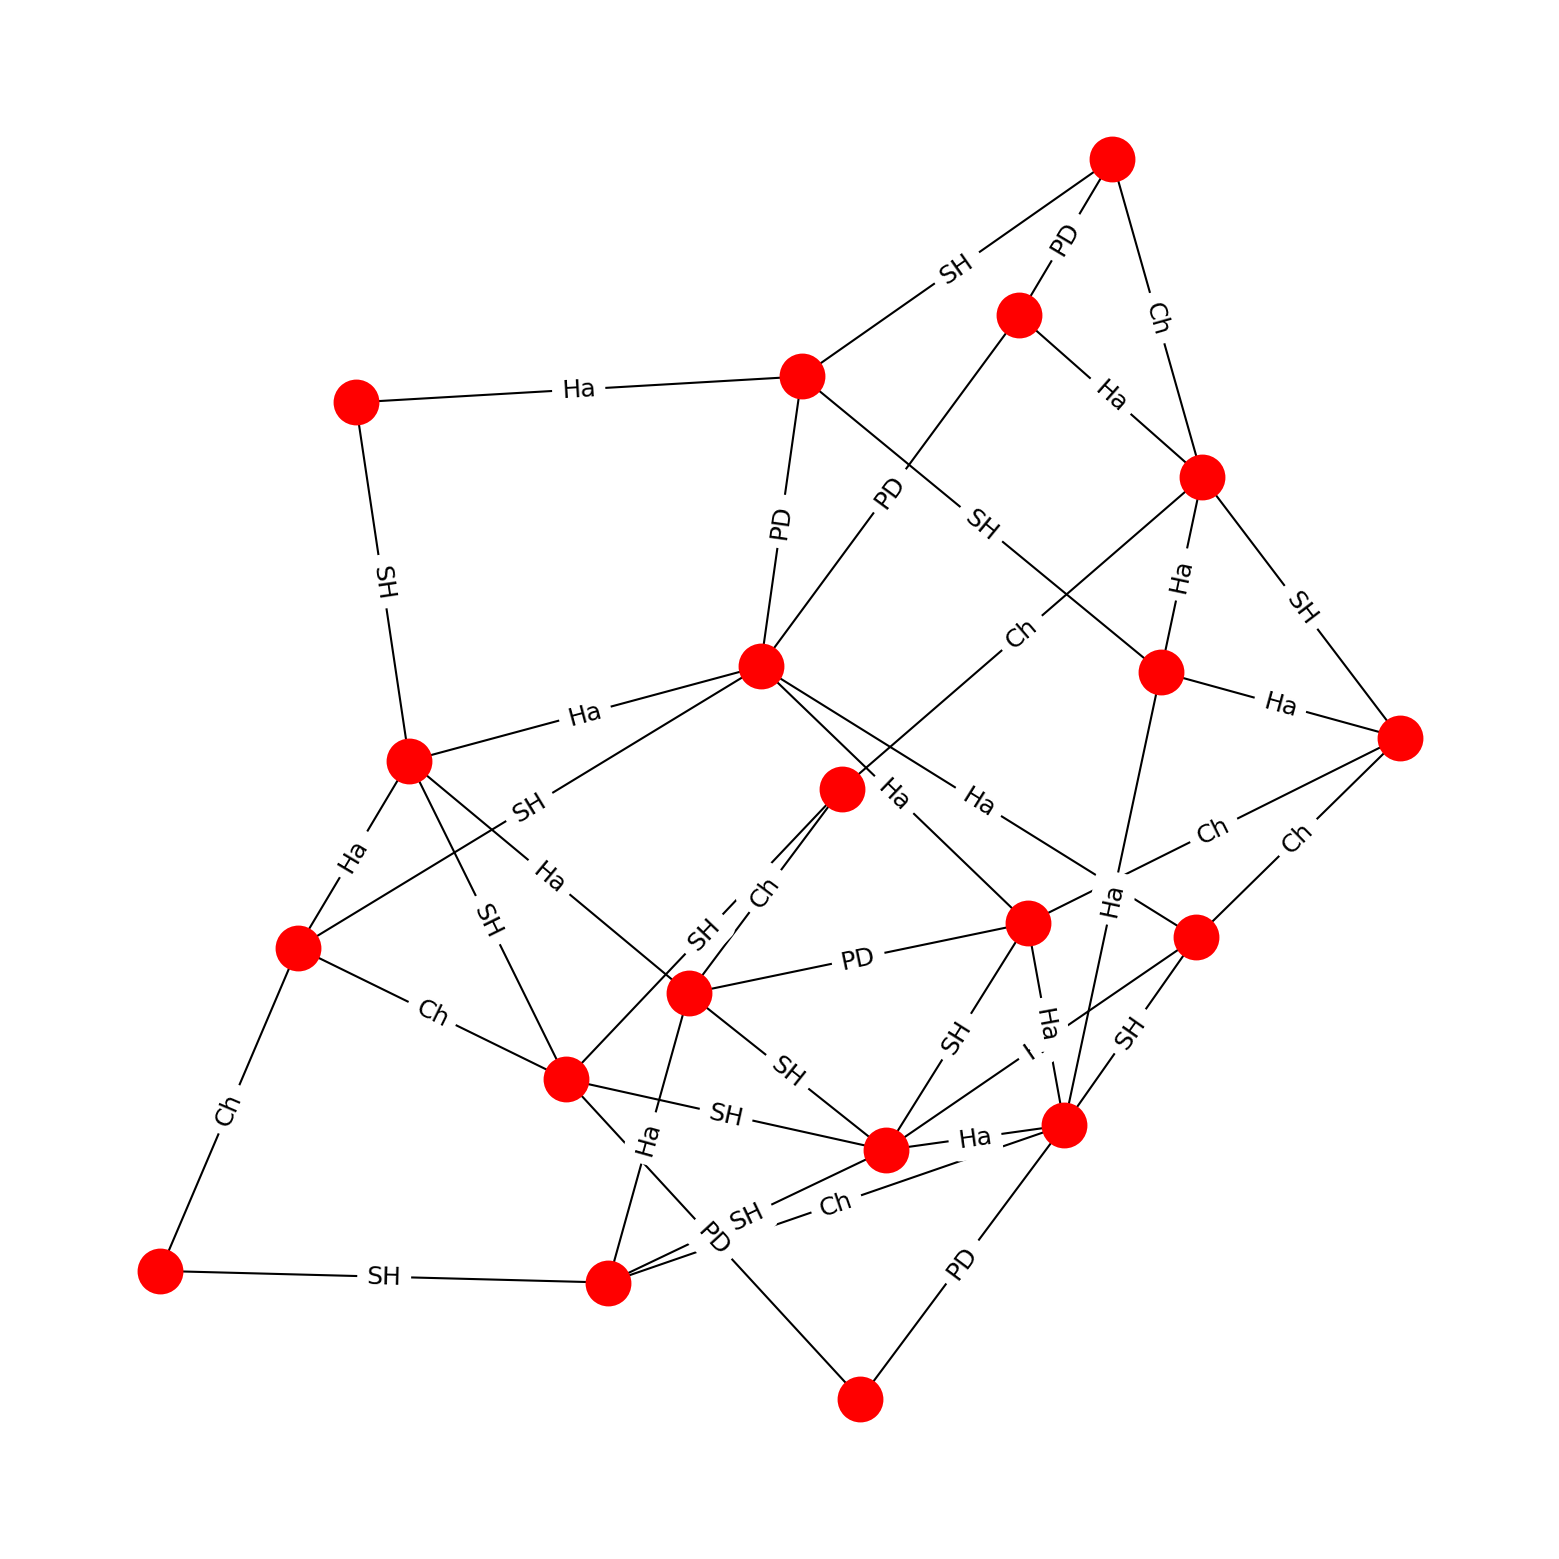

In [103]:
# Predefined constants
n = 20  # Number of nodes
p = 0.2  # Probability of edge creation

# Generate an Erdős-Rényi network
G = nx.erdos_renyi_graph(n, p)

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = list(available_games.values())[np.random.randint(len(available_games))]

# List the edges and their corresponding games
print(f"Simulation: n={G.number_of_nodes()} agents playing {G.number_of_edges()} games")
for edge in G.edges(data=True):
    game = edge[2]['game']
    game_name = get_game_name(game, available_games)
    print(f"{edge[:2]} -- {game_name}")

# Plot the network
plt.figure(figsize=(5, 5), dpi=150)
pos = nx.spring_layout(G)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color='red', 
    edge_color='black', 
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [131]:
T = 50
num_players = len(G.nodes)  # Number of players (nodes in the graph)

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=300.,
        dynamic_precision=True,
        decay=0.9,
        A_learning=False,
        learn_every_t_steps=30,
        learning_offset=8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(
        NetworkAgent(
            id=node, 
            game_matrices=adjacent_games, 
            **agent_kwargs[node]
        )
    )

# Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 99
INFO:root:t=0/50
INFO:root:t=0/50
INFO:root:t=50/50 Simulation complete


## Plotting

Text(0, 0.5, 'q_u')

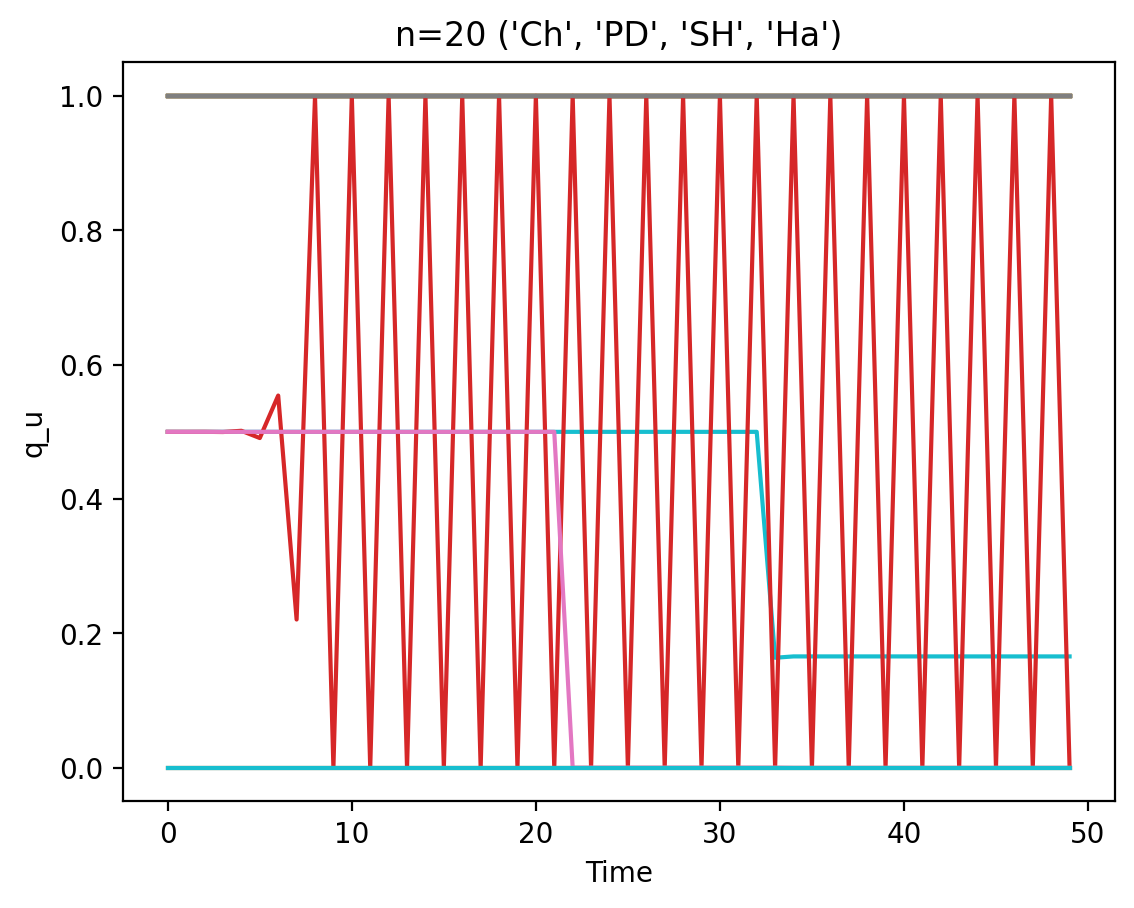

In [132]:
MARGIN = 0.05
q_u_history = np.array(variables_history['q_u'])
for i in range(num_players):
    plt.plot(q_u_history[:, i, 0], label='Agent 0')  # indices: time, agent, action
plt.ylim(0-MARGIN, 1+MARGIN)
plt.title(f'n={len(G.nodes)} {tuple(available_games.keys())}')
plt.xlabel('Time')
plt.ylabel('q_u')

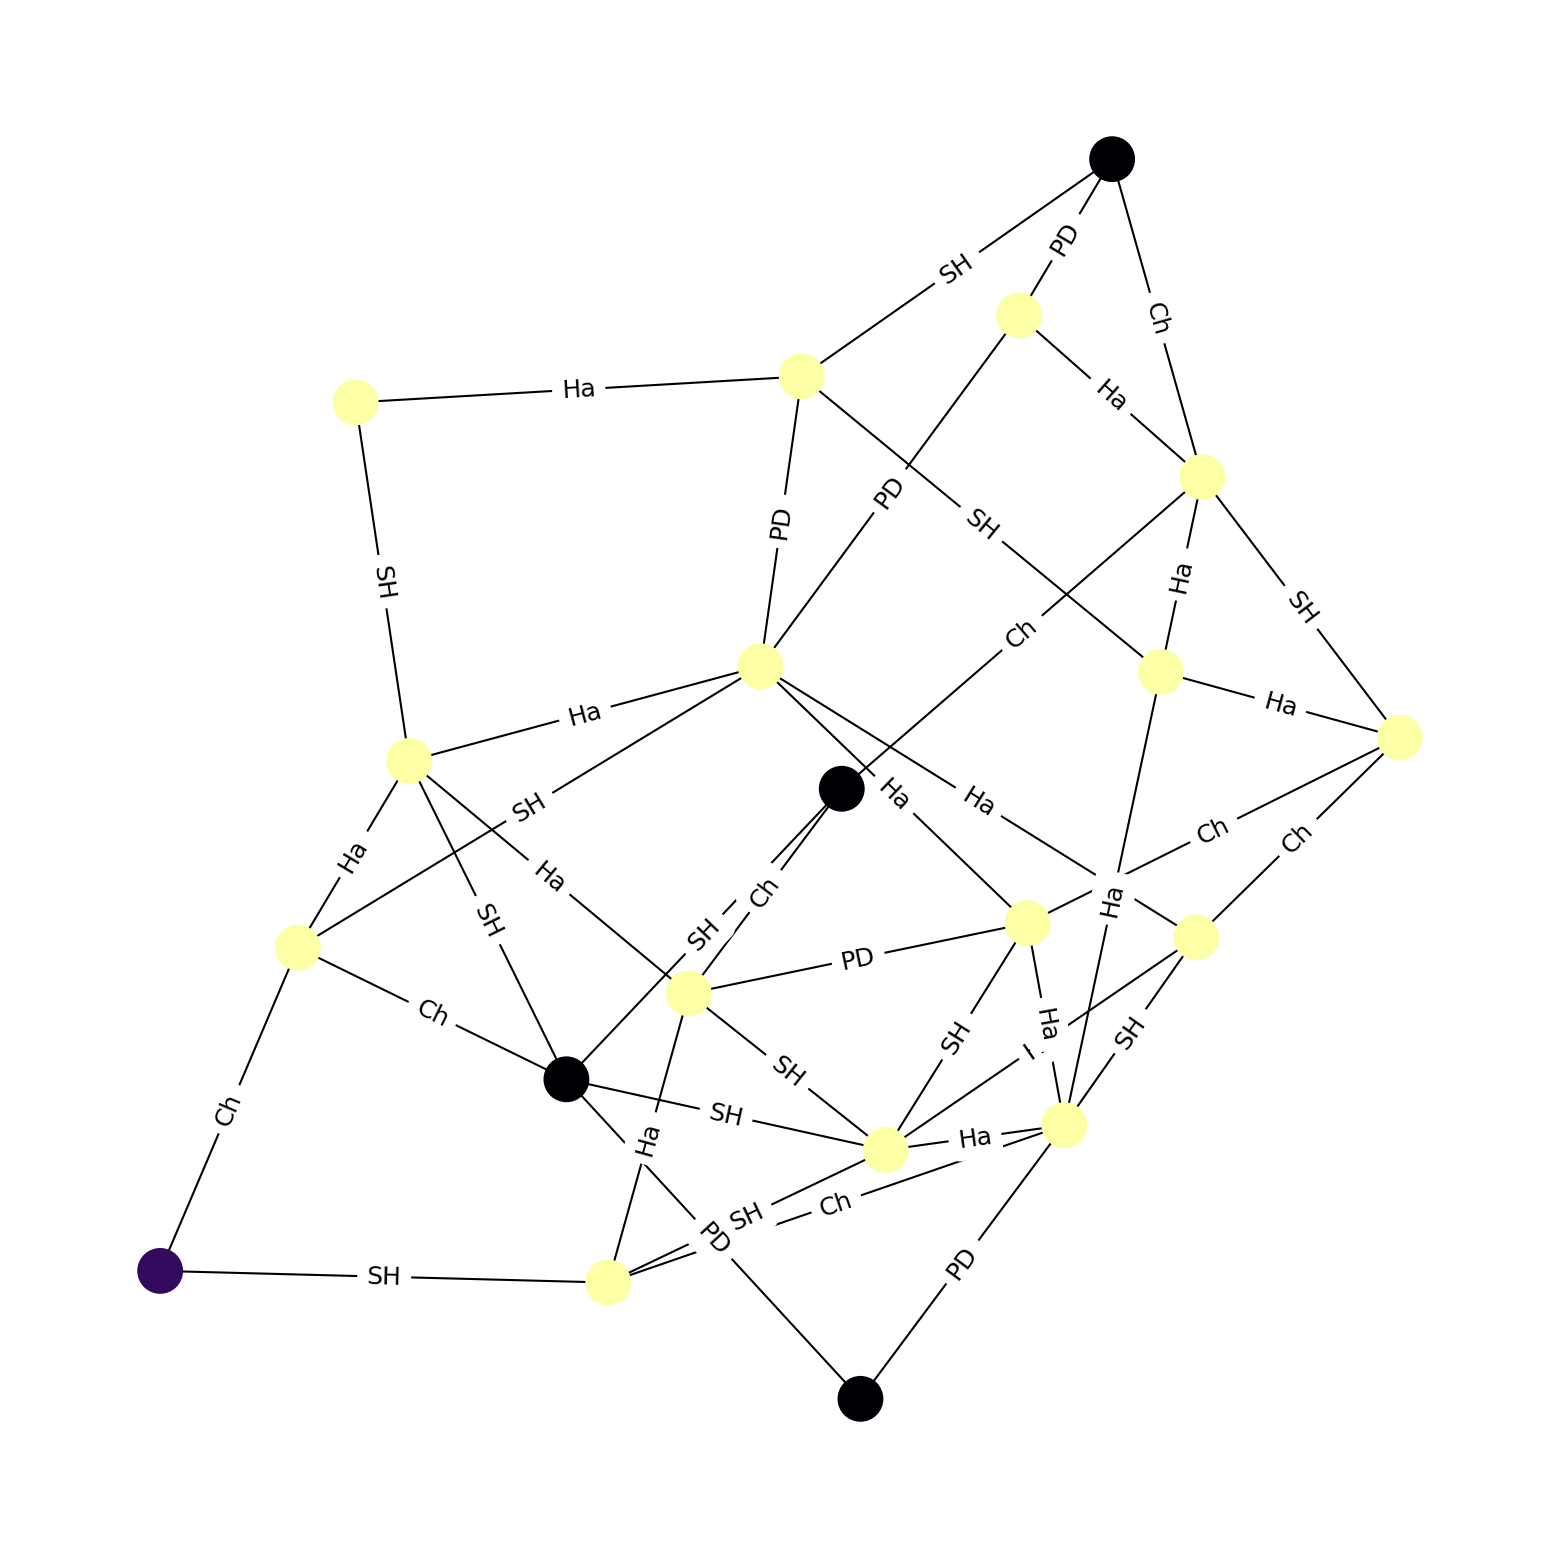

In [133]:
node_intensity = q_u_history[-2, :, 0]  # Extract node intensities
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color=node_intensity, 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [135]:
for i in range(num_players):
    print(variables_history['generative_models_data'][4][i][0])  # indices: time, agent, game

{'accuracy': tensor([-4.13, -4.02]), 'complexity': tensor([0.34, 0.31]), 'energy': tensor([4.82, 4.71]), 'entropy': tensor([0.35, 0.38]), 'ambiguity': tensor([0., 0.]), 'risk': tensor([1.25, 1.25]), 'salience': tensor([0.69, 0.69]), 'pragmatic_value': tensor([-1.94, -1.94]), 'novelty': tensor([0., 0.])}
{'accuracy': tensor([-3.61, -3.30]), 'complexity': tensor([0.33, 0.37]), 'energy': tensor([4.30, 3.99]), 'entropy': tensor([0.36, 0.32]), 'ambiguity': tensor([0., 0.]), 'risk': tensor([0.25, 2.25]), 'salience': tensor([0.69, 0.69]), 'pragmatic_value': tensor([-0.94, -2.94]), 'novelty': tensor([0., 0.])}
{'accuracy': tensor([-4.53, -3.70]), 'complexity': tensor([0.28, 0.30]), 'energy': tensor([5.22, 4.39]), 'entropy': tensor([0.42, 0.39]), 'ambiguity': tensor([0., 0.]), 'risk': tensor([0.25, 2.25]), 'salience': tensor([0.69, 0.69]), 'pragmatic_value': tensor([-0.94, -2.94]), 'novelty': tensor([0., 0.])}
{'accuracy': tensor([-3.95, -4.31]), 'complexity': tensor([0.31, 0.31]), 'energy': te